In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat


In [16]:
df = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


---Model Performance ---
R-squared Score (R2): 0.0291
Mean Absolute Error (MAE):$225,375.25
Intercept: -26048.21
Coefficient (Slope): 267.22

House Price Formula: Price = (267.22 * sqft_living) + -26048.21


<function matplotlib.pyplot.show(close=None, block=None)>

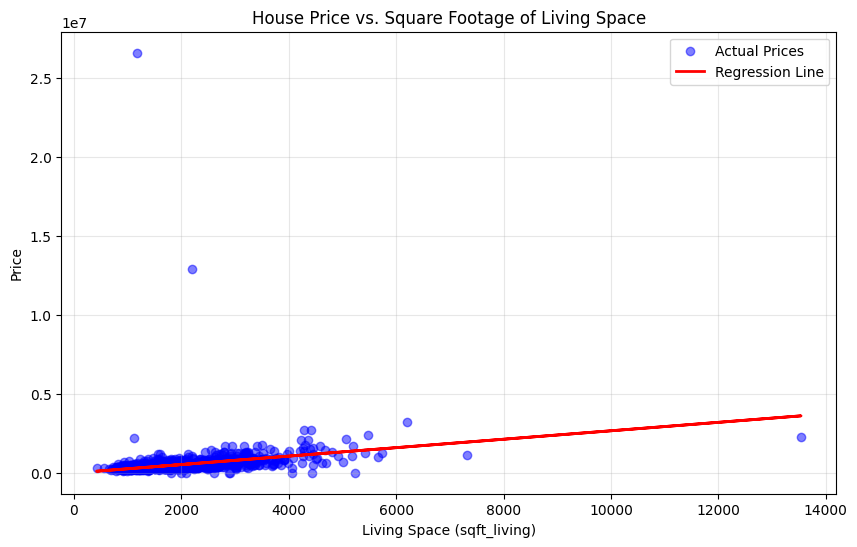

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

#1. Prepare the data
X = df[["sqft_living"]]
y = df[["price"]]

#2. Train/ test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#3. Train Simple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

#4. Make Predictions
y_pred = model.predict(X_test)

#5. Evaluate the model
mae = mean_absolute_error(y_test,y_pred)

r2 = r2_score(y_test, y_pred)

print("---Model Performance ---")
print(f"R-squared Score (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE):${mae:,.2f}")


intercept_val = float(model.intercept_[0])
coef_val = float(model.coef_[0][0])

print(f"Intercept: {intercept_val:.2f}")
print(f"Coefficient (Slope): {coef_val:.2f}")
print(
    f"\nHouse Price Formula: Price = ({coef_val:.2f} * sqft_living) + {intercept_val:.2f}"
)


#6. Visualise the Regression Line
plt.figure(figsize=(10,6))

# Plot actual test data points
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Actual Prices")

# Plot the linear regression prediction line
plt.plot(X_test, y_pred, color="red", linewidth=2, label = "Regression Line")

plt.title("House Price vs. Square Footage of Living Space")
plt.xlabel("Living Space (sqft_living)")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show

New R-squared Score (R2): 0.3767


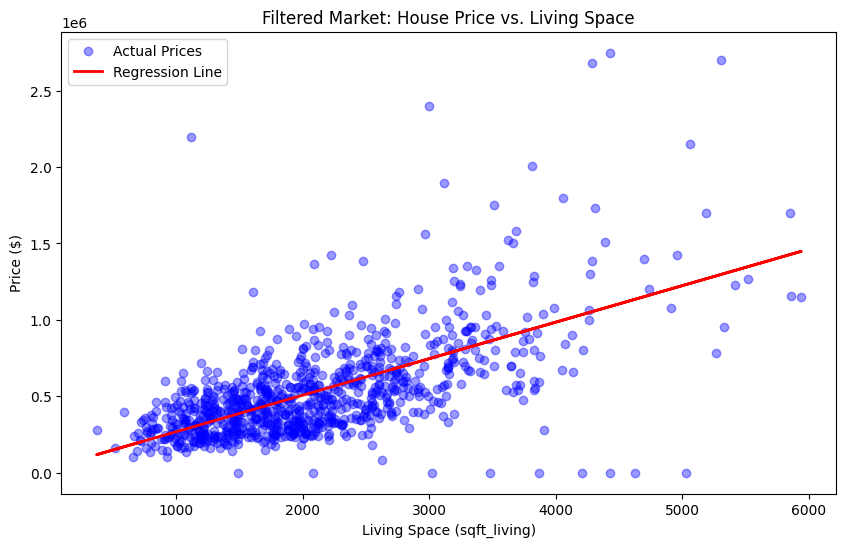

In [19]:
#1.Filter out extreme outliers
# Filter out houses with extreme prices or extreme square footage
df_filtered = df[(df["price"] < 3000000) & (df["sqft_living"] < 6000)]

#2.Re-run with clean data
X_clean = df_filtered[["sqft_living"]]
y_clean = df_filtered["price"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

#3.Train new model
clean_model = LinearRegression()
clean_model.fit(X_train_c, y_train_c)
y_pred_c = clean_model.predict(X_test_c)

#4.Evaluate and Plot
r2_clean = r2_score(y_test_c, y_pred_c)
print(f"New R-squared Score (R2): {r2_clean:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_c, y_test_c, color="blue", alpha=0.4, label="Actual Prices")
plt.plot(X_test_c, y_pred_c, color="red", linewidth=2, label="Regression Line")
plt.title("Filtered Market: House Price vs. Living Space")
plt.xlabel("Living Space (sqft_living)")
plt.ylabel("Price ($)")
plt.legend()
plt.show()